Directorio: /home/coders/Escritorio/emausoft-analytics
Shape ventas: (2823, 34)

Productos unicos: 109
   producto_id producto_nombre         categoria  precio_lista
0            1        S10_1678       Motorcycles            95
1            2        S10_1949      Classic Cars           214
2            3        S10_2016       Motorcycles           118
3            4        S10_4698       Motorcycles           193
4            5        S10_4757      Classic Cars           136
5            6        S10_4962      Classic Cars           147
6            7        S12_1099      Classic Cars           194
7            8        S12_1108      Classic Cars           207
8            9        S12_1666  Trucks and Buses           136
9           10        S12_2823       Motorcycles           150

Categorias:
categoria
Classic Cars        37
Vintage Cars        24
Motorcycles         13
Planes              12
Trucks and Buses    11
Ships                9
Trains               3
Name: count, dtype: 

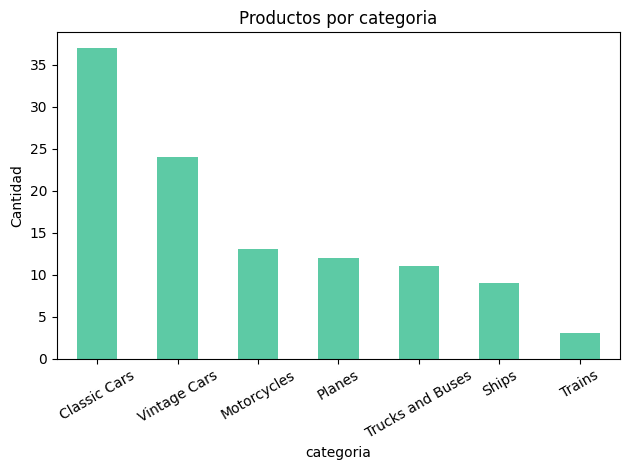

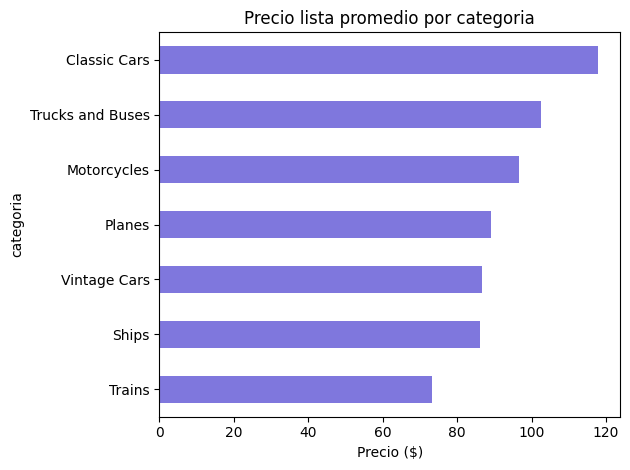

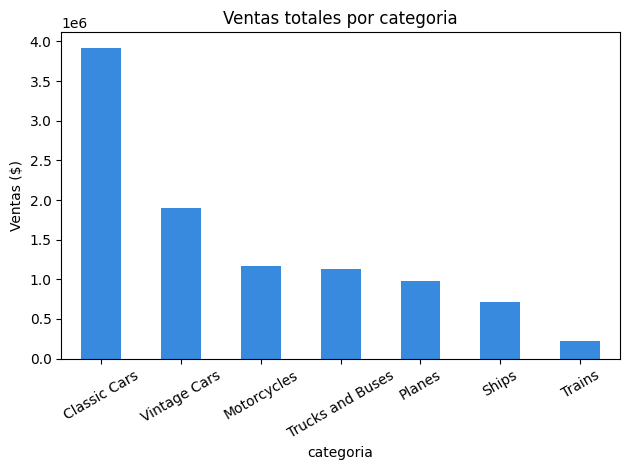


Ventas por categoria:
categoria
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64
Guardados: productos.csv y ventas_con_producto.csv


In [1]:
import os, sys, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path('/home/coders/Escritorio/emausoft-analytics')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print(f'Directorio: {os.getcwd()}')

from src.transformation.build_productos import build_productos, propagar_producto_id

# Carga de ventas enriquecidas

df_ventas = pd.read_csv(ROOT / 'data/interim/ventas_enriquecida.csv')
print(f'Shape ventas: {df_ventas.shape}')

# Construccion de tabla de productos

df_productos = build_productos(df_ventas)
print(f'\nProductos unicos: {len(df_productos)}')
print(df_productos.head(10))

# Analisis de productos

print('\nCategorias:')
print(df_productos['categoria'].value_counts())
print('\nEstadisticas precio_lista:')
print(df_productos['precio_lista'].describe())

 # Grafico de productos por categoria

df_productos['categoria'].value_counts().plot(kind='bar', color='#5DCAA5')
plt.title('Productos por categoria')
plt.ylabel('Cantidad')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Precio lista promedio por categoria

df_productos.groupby('categoria')['precio_lista'].mean().sort_values().plot(
    kind='barh', color='#7F77DD')
plt.title('Precio lista promedio por categoria')
plt.xlabel('Precio ($)')
plt.tight_layout()
plt.show()

# Ventas por categoria

df_vp = propagar_producto_id(df_ventas, df_productos)
ventas_cat = (df_vp
    .merge(df_productos[['producto_id','categoria']], on='producto_id', how='left')
    .groupby('categoria')['SALES']
    .sum()
    .sort_values(ascending=False))

ventas_cat.plot(kind='bar', color='#378ADD')
plt.title('Ventas totales por categoria')
plt.ylabel('Ventas ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('\nVentas por categoria:')
print(ventas_cat)

# Guardar tablas

df_productos.to_csv(ROOT / 'data/interim/productos.csv', index=False)
df_vp.to_csv(ROOT / 'data/interim/ventas_con_producto.csv', index=False)
print('Guardados: productos.csv y ventas_con_producto.csv')